In [28]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense

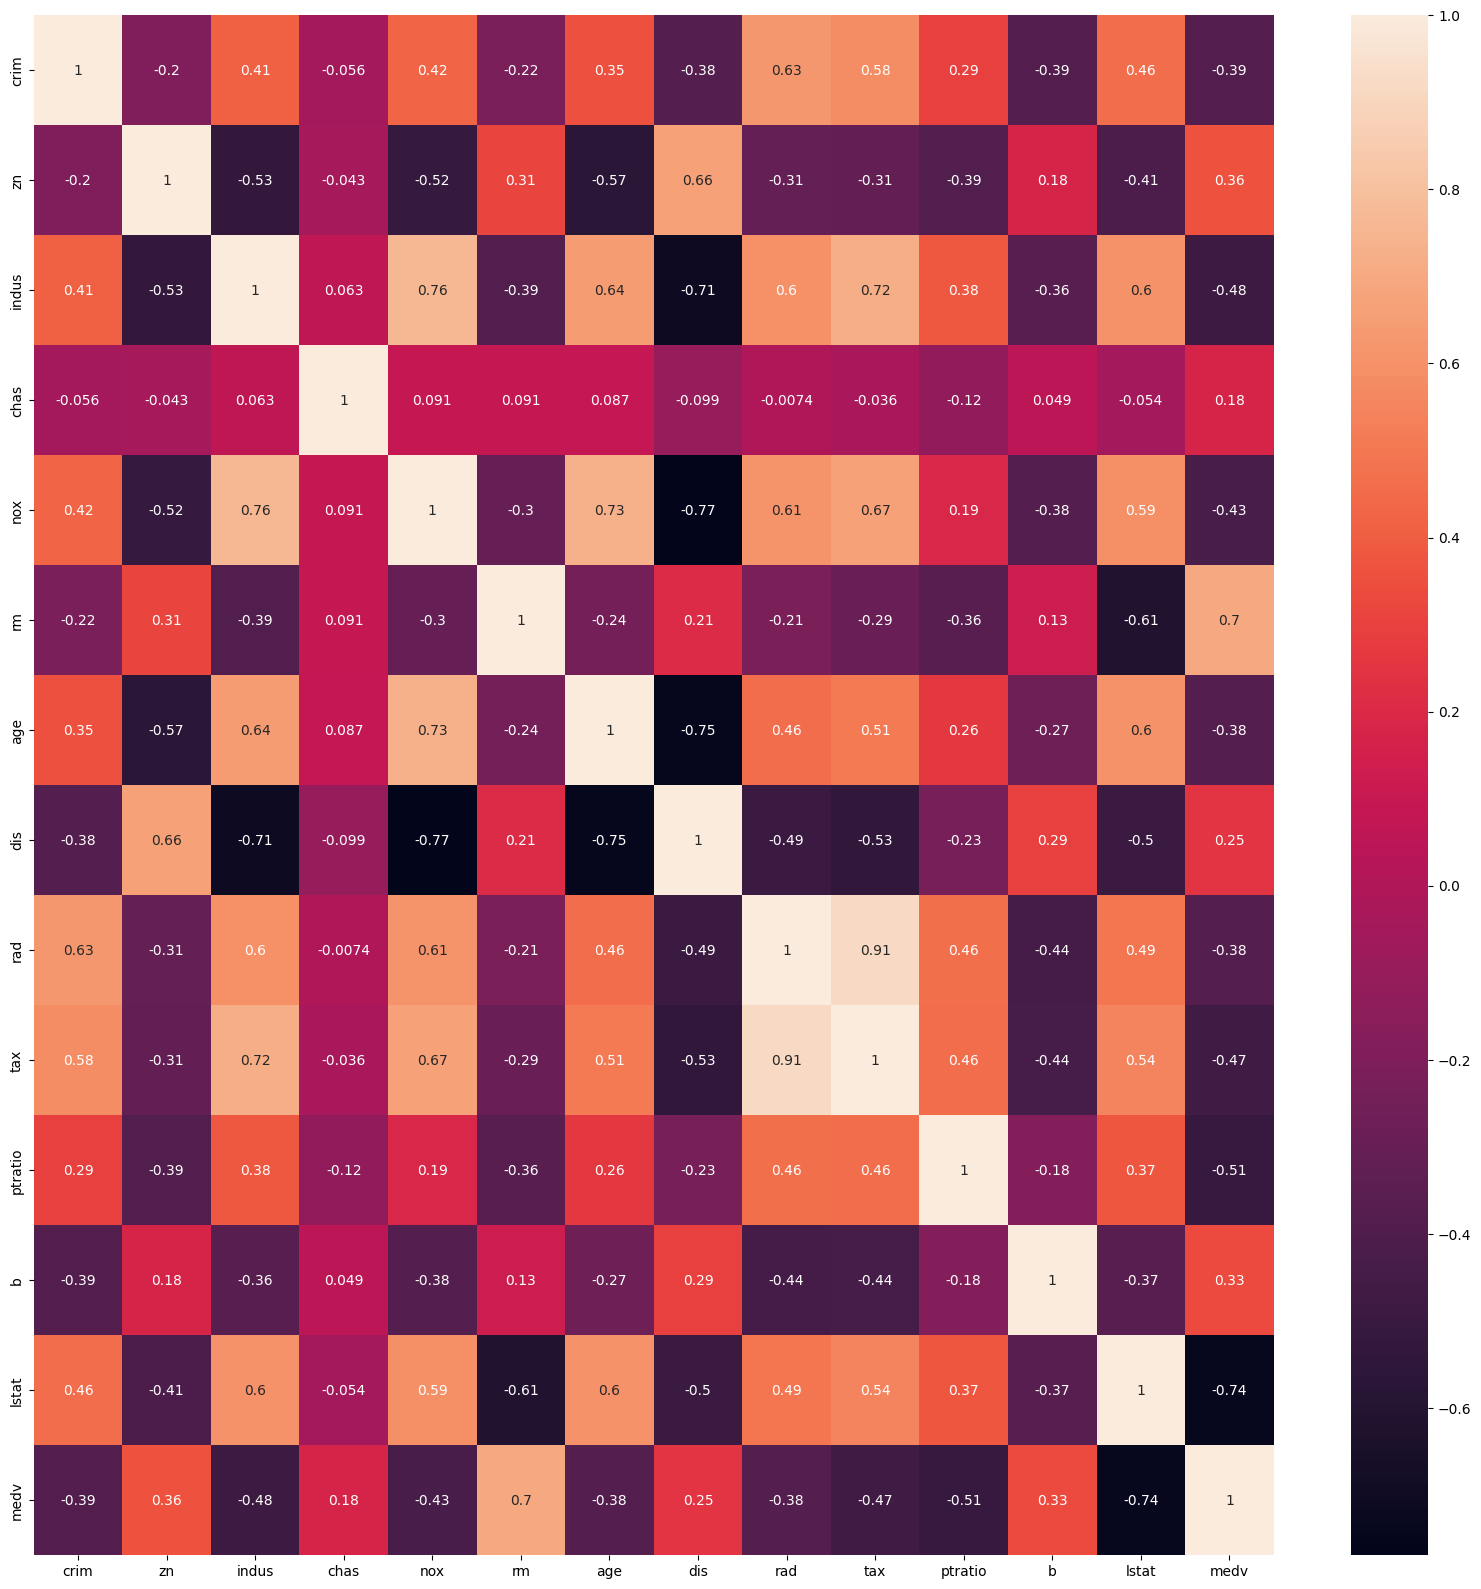

In [ ]:
df = pd.read_csv('BostonHousing.csv')

corr = df.corr()
pyplot.figure(figsize=(20,20))
sns.heatmap(corr,  annot=True)

In [19]:
x = df.drop('medv', axis=1)
y = df['medv']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8)

scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

x_train.shape[1]

13

In [35]:
model  = Sequential([
    Input(shape=(x.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

In [36]:
model.fit(x_train, y_train, epochs=200, verbose=0)

In [37]:
y_pred = model.predict(x_test)

# metrics
import sklearn.metrics as met

a = met.root_mean_squared_error(y_test, y_pred)
b = met.mean_absolute_error(y_test, y_pred)
c = met.r2_score(y_test, y_pred)
print(a, b, c)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4.054196230164488 2.8655267152668515 0.8120427672925001


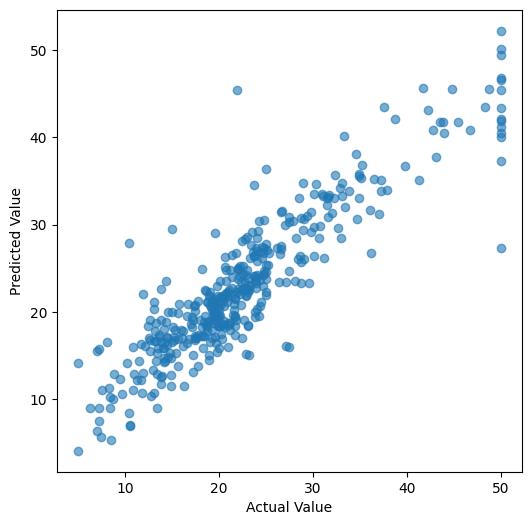

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.show()

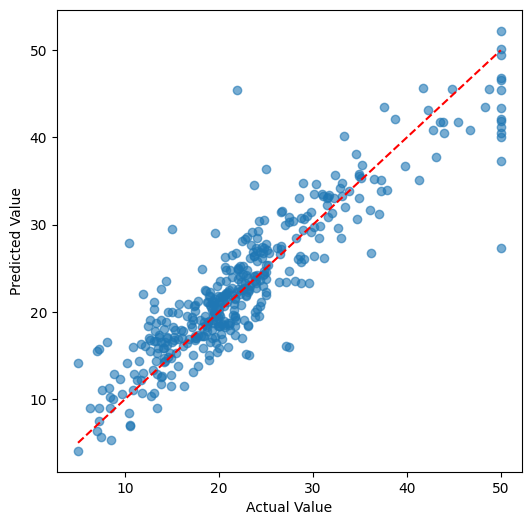

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.show()